In [3]:
import NNMFit
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import os

In [4]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/debug_bdt/plots_fit_result_2D"
os.makedirs(plotting_path, exist_ok=True)

In [5]:
font_axis_label = {'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 22}
font_title      = {'family': 'serif', 'color': 'black', 'weight': 'bold',   'size': 20}
font_legend     = font_manager.FontProperties(family='serif', weight='normal', style='normal', size=13)

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams.update({'font.family': 'serif'})

In [6]:
def plot_2d_scan(
    xs, ys, dllhs,
    best_fits=None,
    labels=None,
    colors=None,
    levels=None,
    levlabels=None,
    x_param="gamma_astro",
    y_param="astro_norm",
    x_label=r"$\gamma$",
    y_label=r"$\Phi_0$",
    heatmap=False,
    legend_title=None,
    ax=None,
    save_path=None,
):
    """Plot 2D likelihood scan contours with optional heatmap overlay.

    Parameters
    ----------
    xs, ys, dllhs : array or list of arrays
        Scan grid coordinates and -2*delta-log-likelihood values.
        Pass a single array for one scan, or a list for comparison.
    best_fits : dict or list of dicts, optional
        Best-fit parameter dicts (keys: x_param, y_param).  One per scan.
    labels : str or list of str, optional
        Legend label per scan.
    colors : str or list of str, optional
        Contour color per scan.  Defaults to black, red, blue, green.
    levels : list of float, optional
        Contour levels.  Default: [2.27, 4.60] (68 %, 90 %).
    levlabels : list of str, optional
        Labels for each contour level.
    x_param, y_param : str
        Keys used to extract best-fit values from the best_fits dicts.
    x_label, y_label : str
        Axis labels.
    heatmap : bool
        If True, draw a color-mapped heatmap of the first scan's dllh.
    legend_title : str, optional
        Title for the legend box.
    ax : matplotlib Axes, optional
        Axes to draw on.  A new figure is created if None.
    save_path : str, optional
        If given, save the figure to this path.

    Returns
    -------
    fig, ax
    """
    # normalise scalars -> lists
    if not isinstance(xs, list):
        xs, ys, dllhs = [xs], [ys], [dllhs]
    n = len(xs)

    if levels    is None: levels    = [2.27, 4.60]
    if levlabels is None: levlabels = ["68%", "90%"]
    if colors    is None: colors    = ["black", "red", "blue", "green"][:n]
    if labels    is None: labels    = [None] * n
    if best_fits is None: best_fits = [None] * n

    if not isinstance(colors,    list): colors    = [colors]
    if not isinstance(labels,    list): labels    = [labels]
    if not isinstance(best_fits, list): best_fits = [best_fits]

    linestyles = ["-", "--"]

    if ax is None:
        fig, ax = plt.subplots(1, 1)
    else:
        fig = ax.get_figure()

    lh, ll = [], []

    for i, (x, y, dllh, color, label, best_fit) in enumerate(
        zip(xs, ys, dllhs, colors, labels, best_fits)
    ):
        if heatmap and i == 0:
            pcm  = ax.pcolor(x, y, dllh, cmap="Blues_r", shading="auto")
            cbar = fig.colorbar(pcm, ax=ax)
            cbar.set_label(r"$-2\Delta\mathrm{log}\mathcal{L}$", size=16, fontfamily="serif")

        cntr = ax.contour(x, y, dllh, levels=levels, colors=color,
                          linewidths=3.5, linestyles=linestyles)

        # contour level labels (only from first scan to avoid duplicates)
        if i == 0:
            h, _ = cntr.legend_elements()
            for j, lev_label in enumerate(levlabels):
                lh.append(h[j])
                ll.append(lev_label)

        if best_fit is not None:
            bfx = best_fit[x_param]
            bfy = best_fit[y_param]
            dot, = ax.plot([bfx], [bfy], "*", color=color, markersize=12)
            bf_label = (f"{label}\n" if label else "") + \
                       r"$\phi_0$ = " + f"{bfx:.2f}, " + r"$\gamma$ = " + f"{bfy:.2f}"
            lh.append(dot)
            ll.append(bf_label)
        elif label is not None:
            lh.append(Line2D([0], [0], color=color, linewidth=2))
            ll.append(label)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if lh:
        ax.legend(lh, ll, loc="lower right", title=legend_title,
                  ncols=1, frameon=True, fancybox=True, shadow=True)

    if save_path:
        fig.savefig(save_path)

    return fig, ax


def combine_scans(xs, ys, dllhs):
    """Combine multiple 2D scans by keeping the lowest dllh at each grid point.

    If all scans share the same grid, the minimum is taken directly (fast path).
    Otherwise every scan is interpolated onto a common grid first (intersection
    of all scan ranges, resolution of the finest scan).

    Parameters
    ----------
    xs, ys : list of array_like
        Grid coordinates as returned by get_scan_xydllh (1-D or 2-D meshgrid).
    dllhs : list of 2-D array_like
        Corresponding -2*delta-log-likelihood values.

    Returns
    -------
    x_out, y_out, dllh_out : arrays
        Same shape as the inputs, with the minimum dllh at every point.
    """
    from scipy.interpolate import RegularGridInterpolator

    xs    = [np.asarray(xi) for xi in xs]
    ys    = [np.asarray(yi) for yi in ys]
    dllhs = [np.asarray(di) for di in dllhs]

    # extract 1-D coordinate vectors from either 1-D or 2-D (meshgrid) arrays
    def _x1d(arr): return arr[0, :] if arr.ndim == 2 else arr
    def _y1d(arr): return arr[:, 0] if arr.ndim == 2 else arr

    x1ds = [_x1d(xi) for xi in xs]
    y1ds = [_y1d(yi) for yi in ys]

    # fast path: all grids are identical
    same_grid = all(
        np.array_equal(x1ds[0], x1d) and np.array_equal(y1ds[0], y1d)
        for x1d, y1d in zip(x1ds[1:], y1ds[1:])
    )
    if same_grid:
        return xs[0], ys[0], np.minimum.reduce(dllhs)

    # slow path: interpolate onto intersection of scan ranges
    x_common = np.linspace(
        max(x1d.min() for x1d in x1ds),
        min(x1d.max() for x1d in x1ds),
        max(len(x1d)  for x1d in x1ds),
    )
    y_common = np.linspace(
        max(y1d.min() for y1d in y1ds),
        min(y1d.max() for y1d in y1ds),
        max(len(y1d)  for y1d in y1ds),
    )
    xmesh, ymesh = np.meshgrid(x_common, y_common)
    pts = np.stack([ymesh.ravel(), xmesh.ravel()], axis=1)  # (N, 2) in (y, x) order

    dllhs_interp = []
    for x1d, y1d, dllh in zip(x1ds, y1ds, dllhs):
        interp = RegularGridInterpolator(
            (y1d, x1d), dllh, method="linear", bounds_error=False, fill_value=np.inf
        )
        dllhs_interp.append(interp(pts).reshape(xmesh.shape))

    return xmesh, ymesh, np.minimum.reduce(dllhs_interp)

In [7]:
scan_dir_dict = {
    "param_scan": "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits_parameter_scan/nbestfit20_gamma_norm_larger_range_2D_225steps/",
    "param_scan2": "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits_parameter_scan/nbestfit20_gamma_norm_larger_range_2D_225steps_round2/",
    "param_scan3": "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits_parameter_scan/nbestfit20_gamma_norm_larger_range_2D_225steps_round3/",
}

drop_unsuccessful = True
x_param, y_param  = "gamma_astro", "astro_norm"

scan_dict = {}
x, y, dllh = {}, {}, {}

for name, scan_dir in scan_dir_dict.items():
    scan_dict[name] = NNMFit.utilities.ScanHandler(scan_dir, dump=False, drop_unsuccessful=drop_unsuccessful)
    x[name], y[name], dllh[name] = scan_dict[name].get_scan_xydllh(
        x=x_param, y=y_param, interpolate=True, drop_unsuccessful=drop_unsuccessful
    )

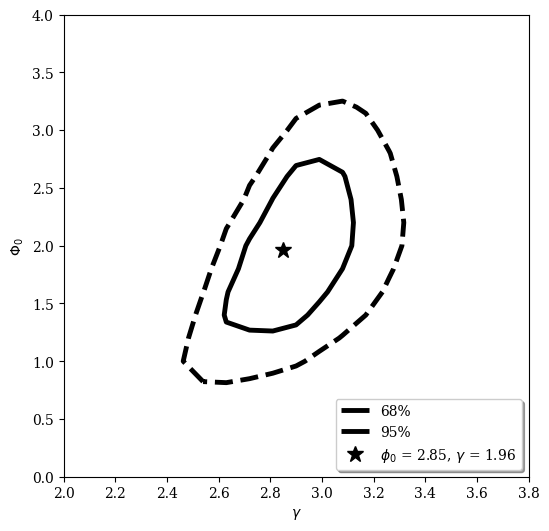

In [9]:
# --- combine scans: take minimum dllh at each grid point ---
names = list(scan_dir_dict.keys())

x_combined, y_combined, dllh_combined = combine_scans(
    xs    = [x[n]    for n in names],
    ys    = [y[n]    for n in names],
    dllhs = [dllh[n] for n in names],
)

# use best fit from whichever scan has the global minimum
best_scan = names[np.argmin([di.min() for di in [dllh[n] for n in names]])]
best_fit_combined = scan_dict[best_scan].get_freefit(drop_unsuccessful=True)

fig, ax = plot_2d_scan(
    x_combined, y_combined, dllh_combined,
    best_fits = best_fit_combined,
    heatmap   = False,
    x_param   = x_param,
    y_param   = y_param,
    levels    = [2.27, 5.99],
    levlabels = ["68%", "95%"],
)

fig.savefig(f"{plotting_path}/contour_combined.pdf")

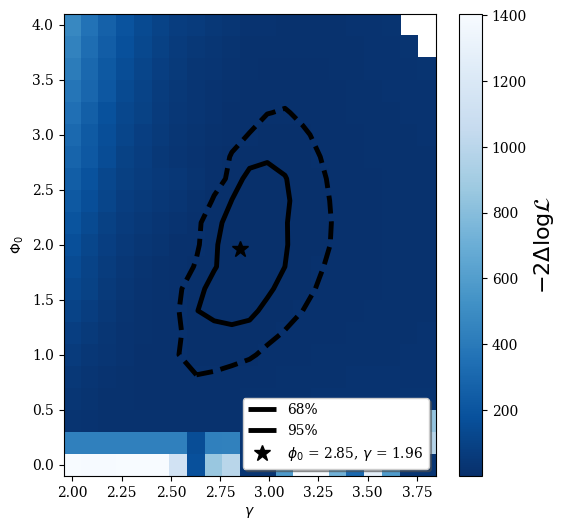

In [10]:
# --- single scan: contours + optional heatmap ---
name      = "param_scan"
best_fit  = scan_dict[name].get_freefit(drop_unsuccessful=True)

fig, ax = plot_2d_scan(
    x[name], y[name], dllh[name],
    best_fits  = best_fit,
    heatmap    = True,
    x_param    = x_param,
    y_param    = y_param,
    levels     = [2.27, 5.99],
    levlabels  = ["68%", "95%"]
)

fig.savefig(f"{plotting_path}/contour_heatmap_{name}.pdf")

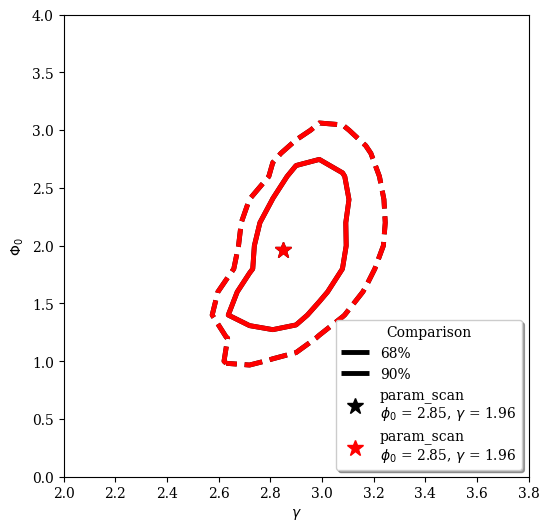

In [11]:
# --- comparison: overlay contours from two scans ---
name1 = "param_scan"
name2 = "param_scan"  # replace with a second scan name

best_fit1 = scan_dict[name1].get_freefit(drop_unsuccessful=True)
best_fit2 = scan_dict[name2].get_freefit(drop_unsuccessful=True)

fig, ax = plot_2d_scan(
    xs         = [x[name1],    x[name2]],
    ys         = [y[name1],    y[name2]],
    dllhs      = [dllh[name1], dllh[name2]],
    best_fits  = [best_fit1,   best_fit2],
    labels     = [name1,       name2],
    colors     = ["black",     "red"],
    levels     = [2.27, 4.60],
    levlabels  = ["68%", "90%"],
    x_param    = x_param,
    y_param    = y_param,
    heatmap    = False,
    legend_title = "Comparison",
)

# fig.savefig(f"{plotting_path}/compare_contour.pdf")

Compare with HESE-7.5

In [12]:
import scipy.special

# HESE 7.5 scan data
params_llhs   = np.loadtxt("astro_scan_data_hese7.5.txt")
BF_params_llh = [2.87375956, 6.36488608 / 3, 122.95919881139868]  # [gamma, phi0, -LLH]

astrogamma = params_llhs[:, 0]
astronorm  = params_llhs[:, 1] / 3
llhs       = params_llhs[:, 2]

# CL levels: 1σ and 2σ for 2 dof
sigmas      = np.array([1, 2])
proportions = scipy.special.erf(sigmas / np.sqrt(2.0))
hese_levels = scipy.special.gammaincinv(2 / 2.0, proportions)

ng, nn  = len(np.unique(astrogamma)), len(np.unique(astronorm))
G_hese  = astrogamma.reshape(ng, nn)
N_hese  = astronorm.reshape(ng, nn)
Z_hese  = (llhs - BF_params_llh[2]).reshape(ng, nn)

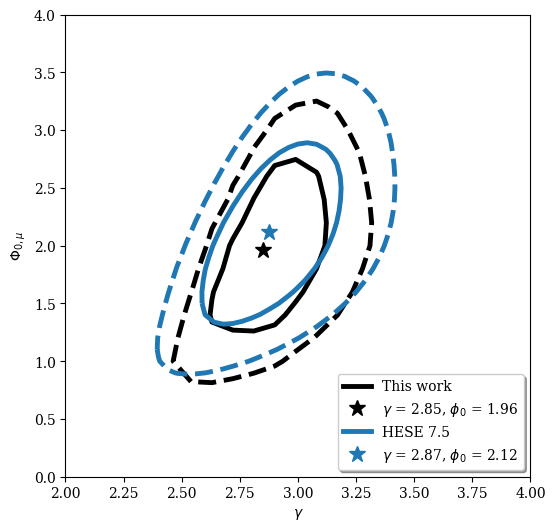

In [16]:
our_color  = "black"
hese_color = "C0"
lw         = 3.5
linestyles = ["-", "--"]
our_levels = [2.27, 5.99]
levlabels  = ["68%", "95%"]

fig, ax = plt.subplots(1, 1)

# our combined scan
cntr_ours = ax.contour(
    x_combined, y_combined, dllh_combined,
    levels=our_levels, colors=our_color, linewidths=lw, linestyles=linestyles,
)
bfx = best_fit_combined[x_param]
bfy = best_fit_combined[y_param]
dot_ours, = ax.plot([bfx], [bfy], "*", color=our_color, markersize=12)

# HESE 7.5
cntr_hese = ax.contour(
    G_hese, N_hese, Z_hese,
    levels=hese_levels, colors=hese_color, linewidths=lw, linestyles=linestyles,
)
dot_hese, = ax.plot([BF_params_llh[0]], [BF_params_llh[1]], "*", color=hese_color, markersize=12)

# legend: one entry per contour level (linestyle), then one colour proxy per analysis
h_levels, _ = cntr_ours.legend_elements()
lh = [
    Line2D([0], [0], color=our_color,  linewidth=lw),
    dot_ours,
    Line2D([0], [0], color=hese_color, linewidth=lw),
    dot_hese,
]
ll = [
    "This work",
    r"$\gamma$ = " + f"{bfx:.2f}, " + r"$\phi_0$ = " + f"{bfy:.2f}",
    "HESE 7.5",
    r"$\gamma$ = " + f"{BF_params_llh[0]:.2f}, " + r"$\phi_0$ = " + f"{BF_params_llh[1]:.2f}",
]

ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\Phi_{0,\mu}$")
ax.legend(lh, ll, loc="lower right", ncols=1, frameon=True, fancybox=True, shadow=True)

fig.savefig(f"{plotting_path}/contour_combined_compare_hese7.5.pdf", bbox_inches="tight")